In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [19]:
df = pd.read_csv('../../Datos/df_general.csv')


In [20]:
# 2. Separar las muestras por la clase principal
df_reales = df[df['Key'] != 'spoof']
df_falsos = df[df['Key'] == 'spoof']

# --- 3. SELECCIÓN DE 2000 MUESTRAS BALANCEADAS ---

# A) Voces Reales: Tomamos 1000 al azar
reales_train, _ = train_test_split(
    df_reales, 
    train_size=1000, 
    random_state=42
)

# B) Voces Falsas (TODOS los ataques): Tomamos 1000 estratificando por Spoofing_ID
falsos_train, _ = train_test_split(
    df_falsos, 
    train_size=1000, 
    stratify=df_falsos['Spoofing_ID'], # Garantiza que el RF aprenda de cada tipo de ataque
    random_state=42
)

# 4. Construir el DataFrame de Entrenamiento final y desordenarlo
df_train = pd.concat([reales_train, falsos_train]).sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Separar Features (X) y Target (y)
columnas_a_excluir = ['file_name', 'User_ID', 'Spoofing_ID', 'Key']

X_train = df_train.drop(columns=columnas_a_excluir)
y_train = df_train['Key']

# 6. Entrenar el Random Forest (250 estimadores)
print("Entrenando Random Forest Genérico (250 árboles)...")
rf_model = RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

Entrenando Random Forest Genérico (250 árboles)...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric


=== TOP CARACTERÍSTICAS MÁS IMPORTANTES ===
            Feature  Importancia  Importancia_Acumulada
spec_bandwidth_mean     0.169425               0.169425
          rmse_mean     0.134194               0.303619
  spec_rolloff_mean     0.080433               0.384052
 spec_flatness_mean     0.076186               0.460238
 spec_contrast_mean     0.068342               0.528580
          mfcc_mean     0.061760               0.590339
     zero_crossings     0.054189               0.644528
 spec_centroid_mean     0.051552               0.696080
             energy     0.047434               0.743514
     tempogram_mean     0.045478               0.788992
           freq_iqr     0.044525               0.833517
          freq_maxv     0.026735               0.860252
              tempo     0.022572               0.882824
            freq_q3     0.021075               0.903899
            freq_q1     0.018501               0.922400
          freq_minv     0.018148               0.940549
   

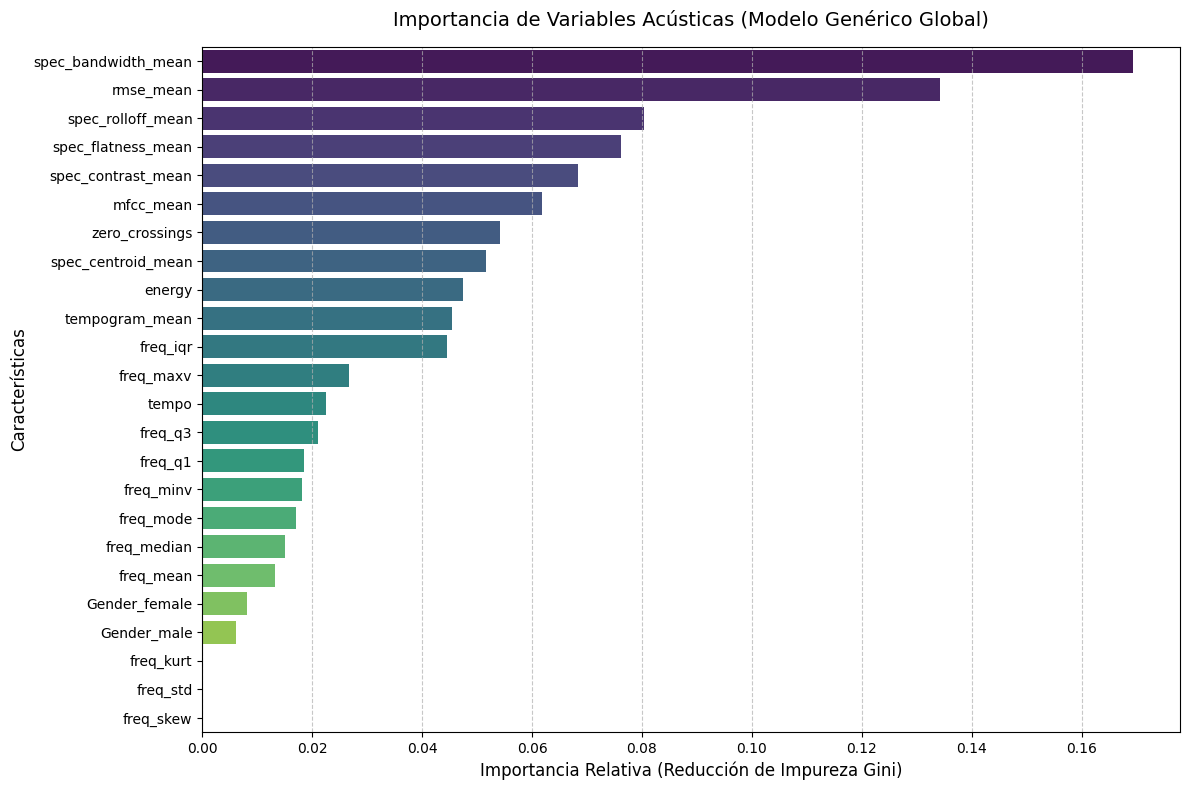

In [21]:
# --- 7. EXTRACCIÓN Y CÁLCULO DE IMPORTANCIA ---

# Extraer importancias y nombres de las características
importancias = rf_model.feature_importances_
nombres_features = X_train.columns

# Crear DataFrame para ordenar y visualizar
df_importancia = pd.DataFrame({
    'Feature': nombres_features,
    'Importancia': importancias
})

# Ordenar de mayor a menor y calcular la suma acumulada
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).reset_index(drop=True)
df_importancia['Importancia_Acumulada'] = df_importancia['Importancia'].cumsum()

print("\n=== TOP CARACTERÍSTICAS MÁS IMPORTANTES ===")
print(df_importancia.to_string(index=False))

# --- 8. GRAFICAR RESULTADOS ---
plt.figure(figsize=(12, 8))
# Usamos hue='Feature' y legend=False para evitar warnings en versiones recientes de Seaborn
sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis', hue='Feature', legend=False)

plt.title('Importancia de Variables Acústicas (Modelo Genérico Global)', fontsize=14, pad=15)
plt.xlabel('Importancia Relativa (Reducción de Impureza Gini)', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [23]:
# 2. Definir tu lista estricta de características ganadoras
features_top = [
    'spec_bandwidth_mean', 'rmse_mean', 'spec_rolloff_mean', 
    'spec_flatness_mean', 'spec_contrast_mean', 'mfcc_mean', 
    'zero_crossings', 'spec_centroid_mean', 'energy', 
    'tempogram_mean', 'freq_iqr'
]

# 3. Separar las muestras por la clase principal (Real vs Spoof)
df_reales = df[df['Key'] != 'spoof']
df_falsos = df[df['Key'] == 'spoof']

# --- 4. PARTICIONADO (2000 Train / Todo el resto a Test) ---

# A) Voces Reales: 1000 para entrenar, el resto para test
reales_train, reales_test = train_test_split(
    df_reales, 
    train_size=1000, 
    random_state=42
)
# B) Voces Falsas (TODOS los ataques): 1000 para entrenar, el resto para test.
# Usamos stratify para garantizar que en las 1000 muestras de entrenamiento
# haya una representación justa de todos los Spoofing_IDs disponibles.
falsos_train, falsos_test = train_test_split(
    df_falsos, 
    train_size=1000, 
    stratify=df_falsos['Spoofing_ID'], 
    random_state=42
)

# 5. Construir y desordenar los DataFrames
df_train = pd.concat([reales_train, falsos_train]).sample(frac=1, random_state=42).reset_index(drop=True)
df_test = pd.concat([reales_test, falsos_test]).sample(frac=1, random_state=42).reset_index(drop=True)

# 6. Separar X e y ¡USANDO SOLO LAS CARACTERÍSTICAS SELECCIONADAS!
X_train = df_train[features_top]
y_train = df_train['Key']

X_test = df_test[features_top]
y_test = df_test['Key']

In [24]:
print(f"[INFO] Muestras para Entrenamiento: {len(y_train)} (Balanceado)")
print(f"[INFO] Muestras para Test: {len(y_test)} (Desbalance natural del mundo real)")
print(f"[INFO] Características utilizadas: {len(features_top)}")
print("-" * 50)

# 7. Entrenar Modelo
rf_model = RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 8. Evaluar
y_pred = rf_model.predict(X_test)

# 9. Mostrar Resultados
print("\n=== RESULTADOS GLOBALES DEL MODELO SIMPLIFICADO ===")
print(f"Precisión global (Accuracy): {accuracy_score(y_test, y_pred):.4f}\n")

print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

[INFO] Muestras para Entrenamiento: 2000 (Balanceado)
[INFO] Muestras para Test: 92632 (Desbalance natural del mundo real)
[INFO] Características utilizadas: 11
--------------------------------------------------

=== RESULTADOS GLOBALES DEL MODELO SIMPLIFICADO ===
Precisión global (Accuracy): 0.8239

Reporte de Clasificación:
              precision    recall  f1-score   support

    bonafide       0.28      0.88      0.43      6950
       spoof       0.99      0.82      0.90     85682

    accuracy                           0.82     92632
   macro avg       0.64      0.85      0.66     92632
weighted avg       0.94      0.82      0.86     92632

Matriz de Confusión:
[[ 6125   825]
 [15489 70193]]
